In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('../.data/EJSCREEN_2023_Tracts_StatePct_with_AS_CNMI_GU_VI.csv')

df.describe()

,OID_,ID,REGION,ACSTOTPOP,ACSIPOVBAS,ACSEDUCBAS,ACSTOTHH,ACSTOTHU,ACSUNEMPBAS,DEMOGIDX_2,...,P_D2_PWDIS,P_D5_PWDIS,AREALAND,AREAWATER,NPL_CNT,TSDF_CNT,EXCEED_COUNT_80,EXCEED_COUNT_80_SUP,Shape_Length,Shape_Area
count,86081.000000,8.608100e+04,86081.000000,86080.000000,86074.000000,86074.000000,86074.000000,86074.000000,86074.000000,86074.000000,...,82525.000000,82525.000000,8.608000e+04,8.608000e+04,86081.000000,86081.000000,86081.000000,85395.000000,86081.000000,8.608100e+04
mean,43041.000000,2.818707e+10,5.226670,3872.743309,3781.454981,2645.927562,1457.953377,1641.949148,1952.173374,0.354740,...,49.490615,49.491548,1.064203e+08,8.187938e+06,0.015950,0.197395,2.563946,2.576205,0.300332,1.357979e-02
std,24849.588598,1.659916e+10,2.467505,1739.028231,1731.398046,1178.880444,640.361882,702.315425,964.300995,0.212896,...,28.902088,28.900535,1.289342e+09,2.111219e+08,0.135356,0.709795,3.923111,3.831340,0.724345,2.668094e-01
min,1.000000,6.000100e+06,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.003416,5.686515e-07
25%,21521.000000,1.211301e+10,4.000000,2670.000000,2592.000000,1836.000000,1022.000000,1179.000000,1274.000000,0.184819,...,24.000000,24.000000,1.667068e+06,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.063170,1.784703e-04
50%,43041.000000,2.716307e+10,5.000000,3723.500000,3639.000000,2557.000000,1409.000000,1591.000000,1857.000000,0.299540,...,50.000000,50.000000,4.439304e+06,2.151750e+04,0.000000,0.000000,0.000000,0.000000,0.110775,4.872649e-04
75%,64561.000000,4.200760e+10,7.000000,4918.000000,4823.000000,3360.000000,1846.000000,2056.000000,2532.000000,0.501540,...,75.000000,75.000000,2.752800e+07,4.397378e+05,0.000000,0.000000,4.000000,4.000000,0.299655,3.151997e-03
max,86081.000000,7.215375e+10,10.000000,38223.000000,27579.000000,17537.000000,8419.000000,13092.000000,13450.000000,1.000000,...,100.000000,100.000000,2.215858e+11,2.598970e+10,5.000000,35.000000,13.000000,13.000000,60.846295,5.334680e+01


In [4]:
# Columns to exclude from correlation/PCA (IDs, names, geometry)
EXCLUDE_COLS = ["OID_", "ID", "STATE_NAME", "ST_ABBREV", "CNTY_NAME", "Shape_Length", "Shape_Area"]

def get_numeric_for_analysis(df, state_abbrev=None):
    """Subset to state (optional) and numeric columns only."""
    out = df[df["ST_ABBREV"] == state_abbrev].copy() if state_abbrev else df.copy()
    numeric = out.select_dtypes(include=["number"])
    return numeric.drop(columns=[c for c in EXCLUDE_COLS if c in numeric.columns], errors="ignore")

In [5]:
# Pick a state (e.g. "IN", "CA", "TX") or None for all tracts
STATE = "IN"
data = get_numeric_for_analysis(df, state_abbrev=STATE)
# Drop rows with any NaN for correlation/PCA
data_clean = data.dropna()
print(f"Shape: {data_clean.shape} (tracts × variables)")

Shape: (1622, 119) (tracts × variables)


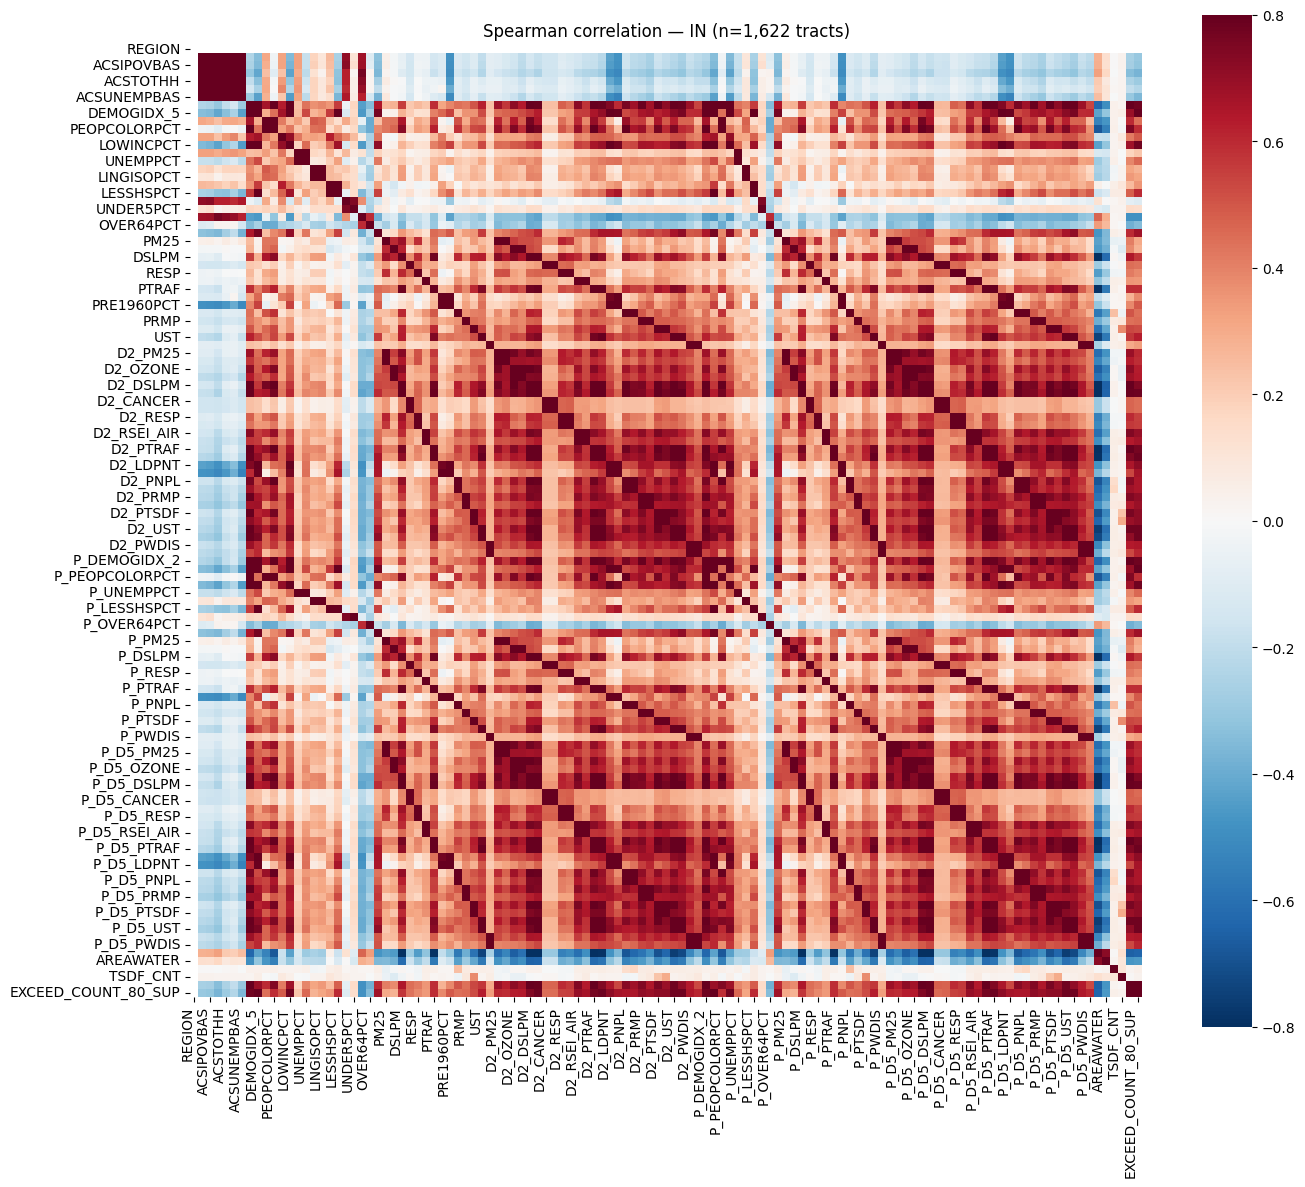

In [6]:
# Correlation heatmap (Spearman for robustness to outliers)
import seaborn as sns
import matplotlib.pyplot as plt

corr = data_clean.corr(method="spearman")
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-0.8, vmax=0.8, square=True, ax=ax)
ax.set_title(f"Spearman correlation — {STATE or 'all states'} (n={len(data_clean):,} tracts)")
plt.xticks(rotation=90, ha="right")
plt.tight_layout()
plt.show()

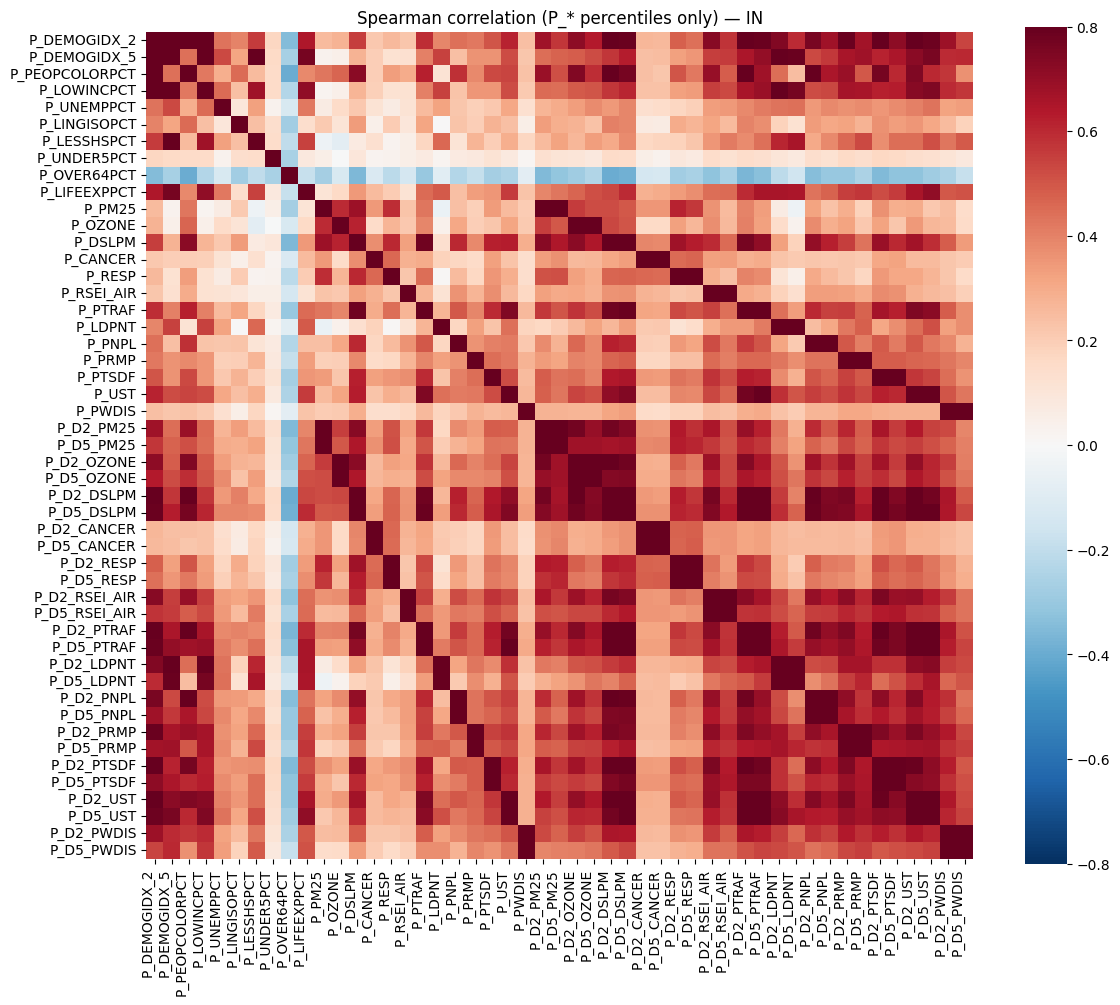

In [7]:
# Optional: heatmap for a subset of columns (e.g. percentiles only) — easier to read
p_cols = [c for c in data_clean.columns if c.startswith("P_")]
if p_cols:
    corr_p = data_clean[p_cols].corr(method="spearman")
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(corr_p, cmap="RdBu_r", center=0, vmin=-0.8, vmax=0.8, square=True, ax=ax)
    ax.set_title(f"Spearman correlation (P_* percentiles only) — {STATE or 'all'}")
    plt.xticks(rotation=90, ha="right")
    plt.tight_layout()
    plt.show()

In [ ]:
# PCA (standardize first)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X = scaler.fit_transform(data_clean)
n_components = min(20, X.shape[0], X.shape[1])
pca = PCA(n_components=n_components, random_state=42)
pca.fit(X)
print(f"Fitted PCA with {n_components} components")

Fitted PCA with 20 components


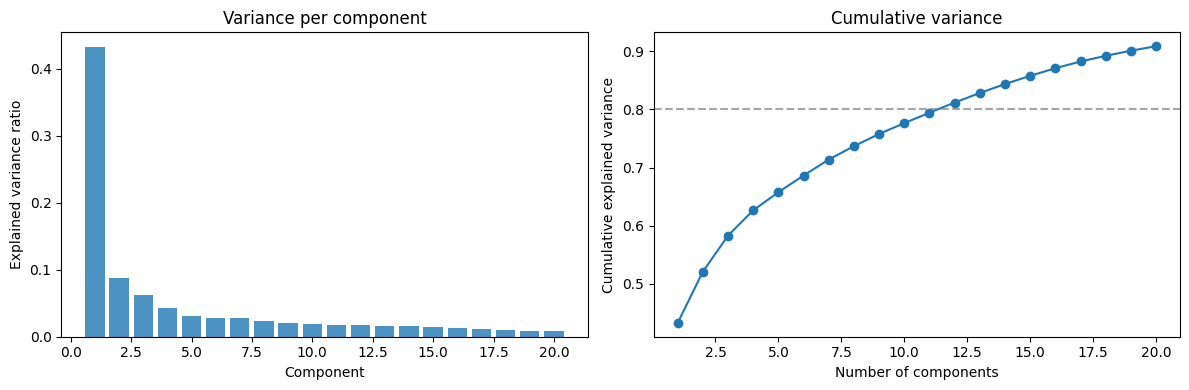

In [ ]:
# Explained variance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, alpha=0.8)
ax1.set_xlabel("Component")
ax1.set_ylabel("Explained variance ratio")
ax1.set_title("Variance per component")
ax2.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_.cumsum(), "o-")
ax2.set_xlabel("Number of components")
ax2.set_ylabel("Cumulative explained variance")
ax2.set_title("Cumulative variance")
ax2.axhline(0.8, color="gray", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Loadings: which variables contribute to each component (first 5)
loadings = pd.DataFrame(
    pca.components_.T[:, :5],
    index=data_clean.columns,
    columns=[f"PC{i+1}" for i in range(5)],
)
# Top 10 by absolute loading per component
for pc in loadings.columns:
    top = loadings[pc].abs().nlargest(10)
    print(f"\n{pc} (var explained: {pca.explained_variance_ratio_[int(pc[2])-1]:.2%})")
    print(loadings.loc[top.index, pc].sort_values(key=abs, ascending=False))


PC1 (var explained: 43.27%)
D5_DSLPM               0.133299
D2_DSLPM               0.130130
D2_PTRAF               0.129338
EXCEED_COUNT_80_SUP    0.127968
D2_UST                 0.127606
P_D5_DSLPM             0.127230
DEMOGIDX_2             0.126973
EXCEED_COUNT_80        0.126958
D5_PTRAF               0.126727
P_D2_DSLPM             0.125983
Name: PC1, dtype: float64

PC2 (var explained: 8.81%)
ACSUNEMPBAS    0.222979
ACSIPOVBAS     0.212605
ACSTOTHH       0.210024
ACSTOTPOP      0.209168
ACSEDUCBAS     0.203422
ACSTOTHU       0.193015
P_PM25         0.189681
P_D5_LDPNT    -0.188023
P_LDPNT       -0.187159
PM25           0.186495
Name: PC2, dtype: float64

PC3 (var explained: 6.21%)
CANCER         0.223308
P_CANCER       0.222672
P_D5_CANCER    0.217207
P_D2_CANCER    0.215998
LOWINCOME     -0.213858
D5_CANCER      0.201215
ACSTOTPOP     -0.188810
UNDER5        -0.187128
ACSIPOVBAS    -0.186365
D2_CANCER      0.184323
Name: PC3, dtype: float64

PC4 (var explained: 4.34%)
OZONE    

In [ ]:
# Regressions: "perfect storm" predictors → health risk
# X: P_DSLPM (Diesel PM), P_PTRAF (Traffic Proximity), DEMOGIDX_2 (demographic index: low income + minority)
# Y: P_CANCER and P_RESP

import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X_vars = ["P_DSLPM", "P_PTRAF", "DEMOGIDX_2"]
reg_df = data_clean[["P_CANCER", "P_RESP"] + X_vars].dropna()
X = reg_df[X_vars]
n = len(reg_df)

# Cancer model
y_cancer = reg_df["P_CANCER"]
model_cancer = LinearRegression().fit(X, y_cancer)
y_cancer_pred = model_cancer.predict(X)
r2_cancer = r2_score(y_cancer, y_cancer_pred)
print("P_CANCER ~ P_DSLPM + P_PTRAF + DEMOGIDX_2")
print(f"  R² = {r2_cancer:.4f}")
print(f"  Coefs: {dict(zip(X_vars, model_cancer.coef_))}, intercept = {model_cancer.intercept_:.4f}\n")

# Respiratory model
y_resp = reg_df["P_RESP"]
model_resp = LinearRegression().fit(X, y_resp)
y_resp_pred = model_resp.predict(X)
r2_resp = r2_score(y_resp, y_resp_pred)
print("P_RESP ~ P_DSLPM + P_PTRAF + DEMOGIDX_2")
print(f"  R² = {r2_resp:.4f}")
print(f"  Coefs: {dict(zip(X_vars, model_resp.coef_))}, intercept = {model_resp.intercept_:.4f}")

P_CANCER ~ P_DSLPM + P_PTRAF + DEMOGIDX_2
  R² = 0.1401
  Coefs: {'P_DSLPM': np.float64(0.3507075078528736), 'P_PTRAF': np.float64(0.008545692885133438), 'DEMOGIDX_2': np.float64(5.641392833052798)}, intercept = -8.0271

P_RESP ~ P_DSLPM + P_PTRAF + DEMOGIDX_2
  R² = 0.3639
  Coefs: {'P_DSLPM': np.float64(0.6823779477531722), 'P_PTRAF': np.float64(-0.03224533922950717), 'DEMOGIDX_2': np.float64(-13.024122347612924)}, intercept = -1.2815


## PCA for every state

Run the same PCA for each state. Output: **one row per (state, PC)** with **PC**, **var_explained**, and the **top 10 variables** (by absolute loading) for that component.

In [ ]:
# PCA for every state: one row per (state, PC) with var_explained and top variables
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

states = sorted(df["ST_ABBREV"].dropna().unique().tolist())
n_pc_max = 20
n_top_vars = 10  # top variables by |loading| per PC
results = []

for st in states:
    data_st = get_numeric_for_analysis(df, state_abbrev=st)
    p_cols = [c for c in data_st.columns if c.startswith("P_")]
    data_st = data_st[p_cols].dropna()
    if data_st.shape[0] < 10 or data_st.shape[1] < 2:
        for pc in range(1, n_pc_max + 1):
            row = {"ST_ABBREV": st, "n_tracts": data_st.shape[0], "PC": pc, "var_explained": None}
            for k in range(1, n_top_vars + 1):
                row[f"top{k}_var"] = None
            results.append(row)
        continue
    scaler = StandardScaler()
    X = scaler.fit_transform(data_st)
    n_comp = min(n_pc_max, X.shape[0], X.shape[1])
    pca = PCA(n_components=n_comp, random_state=42)
    pca.fit(X)
    evr = pca.explained_variance_ratio_
    loadings = pca.components_.T  # (n_vars, n_comp)
    var_names = data_st.columns.tolist()
    for i in range(n_comp):
        pc_num = i + 1
        row = {"ST_ABBREV": st, "n_tracts": len(data_st), "PC": pc_num, "var_explained": round(evr[i], 6)}
        order = np.argsort(np.abs(loadings[:, i]))[::-1]
        for k in range(n_top_vars):
            idx = order[k] if k < len(order) else None
            row[f"top{k+1}_var"] = var_names[idx] if idx is not None else None
        results.append(row)
    for pc_num in range(n_comp + 1, n_pc_max + 1):
        row = {"ST_ABBREV": st, "n_tracts": len(data_st), "PC": pc_num, "var_explained": None}
        for k in range(1, n_top_vars + 1):
            row[f"top{k}_var"] = None
        results.append(row)

pca_by_state = pd.DataFrame(results)
print(pca_by_state.head(15).to_string())
print(f"\nTotal rows (state × PC): {len(pca_by_state)}")

   ST_ABBREV  n_tracts  PC  var_explained top1_var top2_var top3_var top4_var top5_var top6_var top7_var top8_var top9_var top10_var
0         AK         0   1            NaN     None     None     None     None     None     None     None     None     None      None
1         AK         0   2            NaN     None     None     None     None     None     None     None     None     None      None
2         AK         0   3            NaN     None     None     None     None     None     None     None     None     None      None
3         AK         0   4            NaN     None     None     None     None     None     None     None     None     None      None
4         AK         0   5            NaN     None     None     None     None     None     None     None     None     None      None
5         AK         0   6            NaN     None     None     None     None     None     None     None     None     None      None
6         AK         0   7            NaN     None     None     None 

In [ ]:
# Save PCA-by-state results: CSV and XLSX (one row per state)
csv_path = "../.data/pca_by_state.csv"
pca_by_state.to_csv(csv_path, index=False)
print(f"Saved CSV: {csv_path}")

try:
    xlsx_path = "../.data/pca_by_state.xlsx"
    pca_by_state.to_excel(xlsx_path, index=False, sheet_name="PCA by state")
    print(f"Saved XLSX: {xlsx_path}")
except Exception as e:
    print(f"To save XLSX, install openpyxl: pip install openpyxl. Error: {e}")

Saved CSV: ../.data/pca_by_state.csv
Saved XLSX: ../.data/pca_by_state.xlsx


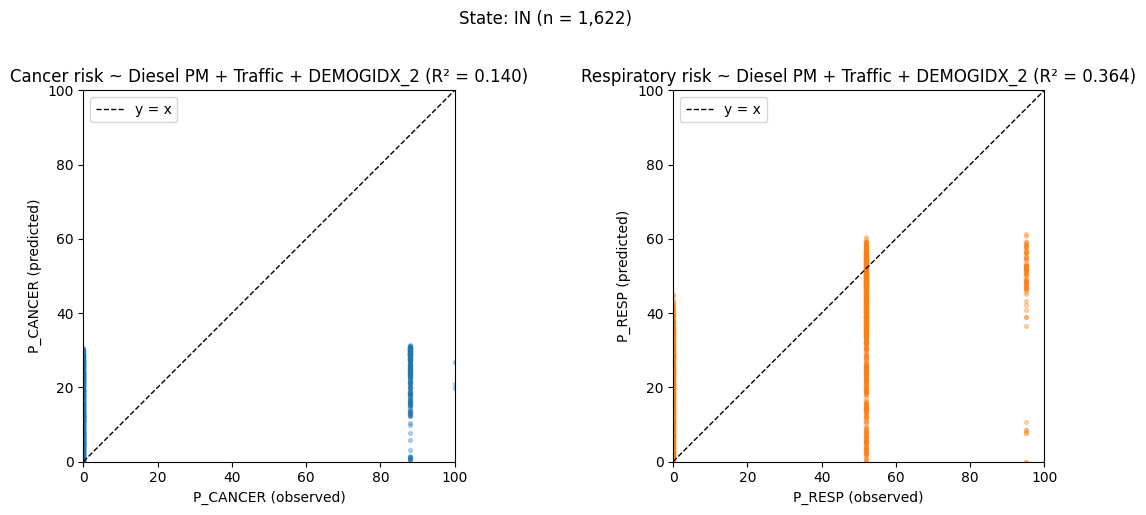

In [ ]:
# Plot: observed vs predicted for both outcomes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Cancer
ax1.scatter(y_cancer, y_cancer_pred, alpha=0.3, s=8)
ax1.plot([0, 100], [0, 100], "k--", lw=1, label="y = x")
ax1.set_xlabel("P_CANCER (observed)")
ax1.set_ylabel("P_CANCER (predicted)")
ax1.set_title(f"Cancer risk ~ Diesel PM + Traffic + DEMOGIDX_2 (R² = {r2_cancer:.3f})")
ax1.legend()
ax1.set_xlim(0, 100)
ax1.set_ylim(0, 100)
ax1.set_aspect("equal")

# Respiratory
ax2.scatter(y_resp, y_resp_pred, alpha=0.3, s=8, color="tab:orange")
ax2.plot([0, 100], [0, 100], "k--", lw=1, label="y = x")
ax2.set_xlabel("P_RESP (observed)")
ax2.set_ylabel("P_RESP (predicted)")
ax2.set_title(f"Respiratory risk ~ Diesel PM + Traffic + DEMOGIDX_2 (R² = {r2_resp:.3f})")
ax2.legend()
ax2.set_xlim(0, 100)
ax2.set_ylim(0, 100)
ax2.set_aspect("equal")

plt.suptitle(f"State: {STATE or 'all'} (n = {n:,})", y=1.02)
plt.tight_layout()
plt.show()

## Resilience: Finding Statistical Outliers

**Question:** Which Indiana tracts are *statistical outliers*—high demographic vulnerability but **lower-than-expected** health risks—and what might drive this resilience?

- The regression explains only part of the variance (e.g. R² ≈ 0.36 → 64% unexplained).
- **Residuals** = observed − predicted: positive = worse than expected, **negative = better than expected** ("beat the odds").
- We define **resilient** tracts = high vulnerability (e.g. high DEMOGIDX_2) + **negative residual** (lower-than-expected P_CANCER or P_RESP).
- Mapping these tracts supports policy (e.g. pair with green space/canopy or zoning data to study protective factors).

In [15]:
# Compute residuals and flag resilient tracts (use same regression sample)
resilience_df = reg_df.copy()
resilience_df["P_CANCER_pred"] = y_cancer_pred
resilience_df["P_RESP_pred"] = y_resp_pred
resilience_df["resid_cancer"] = y_cancer.values - y_cancer_pred
resilience_df["resid_resp"] = y_resp.values - y_resp_pred

# High vulnerability: DEMOGIDX_2 above median (or top quartile)
vuln_threshold = resilience_df["DEMOGIDX_2"].median()  # or .quantile(0.75) for stricter
resilience_df["high_vulnerability"] = resilience_df["DEMOGIDX_2"] >= vuln_threshold

# Resilient = high vulnerability AND negative residual (lower-than-expected risk)
resilience_df["resilient_cancer"] = resilience_df["high_vulnerability"] & (resilience_df["resid_cancer"] < 0)
resilience_df["resilient_resp"] = resilience_df["high_vulnerability"] & (resilience_df["resid_resp"] < 0)

n_resilient_cancer = resilience_df["resilient_cancer"].sum()
n_resilient_resp = resilience_df["resilient_resp"].sum()
n_high_vuln = resilience_df["high_vulnerability"].sum()
print(f"High-vulnerability tracts (DEMOGIDX_2 ≥ median): {n_high_vuln:,}")
print(f"Resilient (high vuln, lower-than-expected cancer risk): {n_resilient_cancer:,}")
print(f"Resilient (high vuln, lower-than-expected resp risk):   {n_resilient_resp:,}")

High-vulnerability tracts (DEMOGIDX_2 ≥ median): 811
Resilient (high vuln, lower-than-expected cancer risk): 609
Resilient (high vuln, lower-than-expected resp risk):   396


In [16]:
# Merge back to get tract ID for mapping (resilience_df.index = original df row index)
map_df = df.loc[resilience_df.index, ["ID", "ST_ABBREV", "CNTY_NAME", "DEMOGIDX_2"]].copy()
map_df = map_df.join(
    resilience_df[["P_CANCER", "P_RESP", "P_CANCER_pred", "P_RESP_pred", "resid_cancer", "resid_resp",
                  "high_vulnerability", "resilient_cancer", "resilient_resp"]],
    how="inner"
)
map_df["geoid11"] = map_df["ID"].astype(str).str.replace("\\D", "", regex=True).str.zfill(11)
print(map_df.head(10).to_string())

                ID ST_ABBREV CNTY_NAME  DEMOGIDX_2  P_CANCER  P_RESP  P_CANCER_pred  P_RESP_pred  resid_cancer  resid_resp  high_vulnerability  resilient_cancer  resilient_resp      geoid11
28267  18001030100        IN     Adams    0.120908       0.0     0.0      -1.614044     7.610375      1.614044   -7.610375               False             False           False  18001030100
28268  18001030200        IN     Adams    0.300866       0.0     0.0       4.849453    12.788415     -4.849453  -12.788415                True              True            True  18001030200
28269  18001030300        IN     Adams    0.202419       0.0     0.0       2.977039    13.023065     -2.977039  -13.023065               False             False           False  18001030300
28270  18001030400        IN     Adams    0.141398       0.0     0.0      -1.908977     6.886845      1.908977   -6.886845               False             False           False  18001030400
28271  18001030500        IN     Adams    0.204026

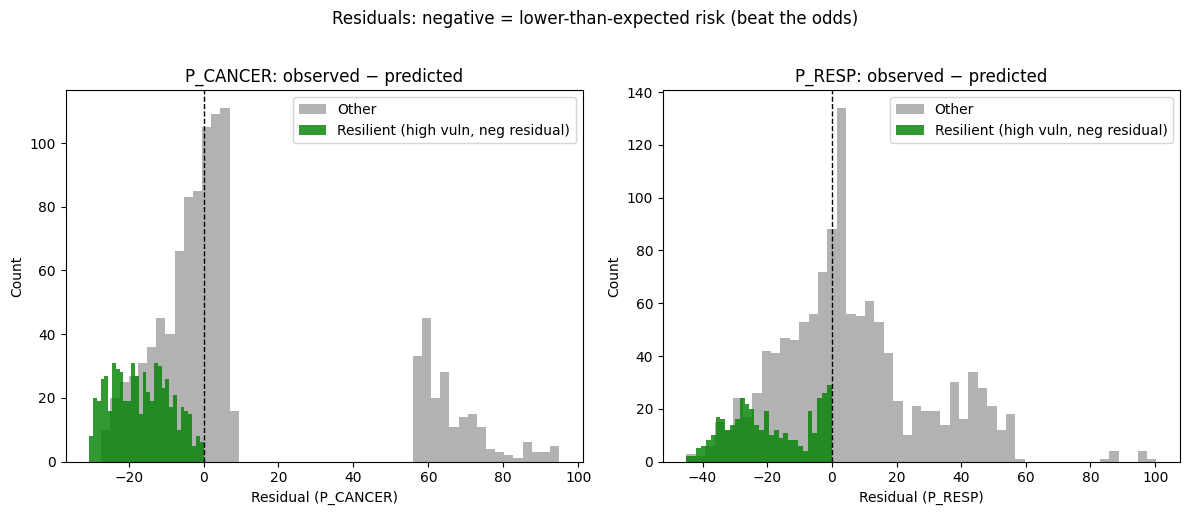

In [17]:
# Residuals distribution and resilient tracts highlighted
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for ax, outcome, resid_col, resilient_col in [
    (ax1, "P_CANCER", "resid_cancer", "resilient_cancer"),
    (ax2, "P_RESP", "resid_resp", "resilient_resp"),
]:
    ax.hist(resilience_df.loc[~resilience_df[resilient_col], resid_col], bins=50, alpha=0.6, label="Other", color="gray")
    ax.hist(resilience_df.loc[resilience_df[resilient_col], resid_col], bins=30, alpha=0.8, label="Resilient (high vuln, neg residual)", color="green")
    ax.axvline(0, color="k", linestyle="--", lw=1)
    ax.set_xlabel(f"Residual ({outcome})")
    ax.set_ylabel("Count")
    ax.set_title(f"{outcome}: observed − predicted")
    ax.legend()

plt.suptitle("Residuals: negative = lower-than-expected risk (beat the odds)", y=1.02)
plt.tight_layout()
plt.show()

In [18]:
# Export for mapping: one row per tract with geoid11, residuals, and resilient flags
# Use geoid11 to join to GeoJSON tract IDs in your web map or QGIS
out_path = f"../.data/resilience_{STATE or 'all'}.csv"
map_df.to_csv(out_path, index=False)
print(f"Saved {len(map_df):,} tracts to {out_path}")
print("Columns: ID, geoid11, CNTY_NAME, DEMOGIDX_2, P_CANCER, P_RESP, predicted values, resid_*, resilient_*")

Saved 1,622 tracts to ../.data/resilience_IN.csv
Columns: ID, geoid11, CNTY_NAME, DEMOGIDX_2, P_CANCER, P_RESP, predicted values, resid_*, resilient_*


## Resilience for every state

Run the same regression and resilience logic for each state. Save tract-level results and residual histograms to `.data`.

In [19]:
# Resilience analysis for every state: regress, residuals, resilient flags, save plot per state
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X_vars = ["P_DSLPM", "P_PTRAF", "DEMOGIDX_2"]
data_dir = Path("../.data")
plots_dir = data_dir / "resilience_plots"
plots_dir.mkdir(parents=True, exist_ok=True)

states = sorted(df["ST_ABBREV"].dropna().unique().tolist())
all_map_dfs = []
summary_rows = []

for st in states:
    data_st = get_numeric_for_analysis(df, state_abbrev=st)
    reg_st = data_st[["P_CANCER", "P_RESP"] + X_vars].dropna()
    if len(reg_st) < 10:
        summary_rows.append({"ST_ABBREV": st, "n_tracts": len(reg_st), "n_resilient_cancer": None, "n_resilient_resp": None, "r2_cancer": None, "r2_resp": None})
        continue
    X = reg_st[X_vars]
    y_c = reg_st["P_CANCER"]
    y_r = reg_st["P_RESP"]
    mod_c = LinearRegression().fit(X, y_c)
    mod_r = LinearRegression().fit(X, y_r)
    pred_c = mod_c.predict(X)
    pred_r = mod_r.predict(X)
    r2_c = r2_score(y_c, pred_c)
    r2_r = r2_score(y_r, pred_r)
    res_df = reg_st.copy()
    res_df["P_CANCER_pred"] = pred_c
    res_df["P_RESP_pred"] = pred_r
    res_df["resid_cancer"] = y_c.values - pred_c
    res_df["resid_resp"] = y_r.values - pred_r
    vuln_med = res_df["DEMOGIDX_2"].median()
    res_df["high_vulnerability"] = res_df["DEMOGIDX_2"] >= vuln_med
    res_df["resilient_cancer"] = res_df["high_vulnerability"] & (res_df["resid_cancer"] < 0)
    res_df["resilient_resp"] = res_df["high_vulnerability"] & (res_df["resid_resp"] < 0)
    map_st = df.loc[res_df.index, ["ID", "ST_ABBREV", "CNTY_NAME", "DEMOGIDX_2"]].copy()
    map_st = map_st.join(res_df[["P_CANCER", "P_RESP", "P_CANCER_pred", "P_RESP_pred", "resid_cancer", "resid_resp", "high_vulnerability", "resilient_cancer", "resilient_resp"]], how="inner")
    map_st["geoid11"] = map_st["ID"].astype(str).str.replace("\\D", "", regex=True).str.zfill(11)
    all_map_dfs.append(map_st)
    summary_rows.append({"ST_ABBREV": st, "n_tracts": len(map_st), "n_resilient_cancer": res_df["resilient_cancer"].sum(), "n_resilient_resp": res_df["resilient_resp"].sum(), "r2_cancer": round(r2_c, 4), "r2_resp": round(r2_r, 4)})
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    for ax, resid_col, res_col in [(ax1, "resid_cancer", "resilient_cancer"), (ax2, "resid_resp", "resilient_resp")]:
        ax.hist(res_df.loc[~res_df[res_col], resid_col], bins=40, alpha=0.6, label="Other", color="gray")
        ax.hist(res_df.loc[res_df[res_col], resid_col], bins=25, alpha=0.8, label="Resilient", color="green")
        ax.axvline(0, color="k", linestyle="--", lw=1)
        ax.set_xlabel(f"Residual")
        ax.set_ylabel("Count")
    ax1.set_title("P_CANCER")
    ax2.set_title("P_RESP")
    plt.suptitle(f"Resilience — {st} (n={len(map_st):,})", y=1.02)
    plt.tight_layout()
    plt.savefig(plots_dir / f"resilience_{st}.png", dpi=100, bbox_inches="tight")
    plt.close()

resilience_by_state_summary = pd.DataFrame(summary_rows)
print(resilience_by_state_summary.head(12).to_string())
print(f"\nSaved {len(states)} residual plots to {plots_dir}")

   ST_ABBREV  n_tracts  n_resilient_cancer  n_resilient_resp  r2_cancer  r2_resp
0         AK       151                26.0              24.0     0.7806   0.7501
1         AL      1434               377.0             305.0     0.2286   0.1777
2         AR       818               336.0             173.0     0.0722   0.1033
3         AS         0                 NaN               NaN        NaN      NaN
4         AZ      1746               534.0             481.0     0.5433   0.7856
5         CA      9073              2674.0            2515.0     0.2917   0.4166
6         CO      1438               379.0             383.0     0.7473   0.7959
7         CT       872               321.0             175.0     0.1349   0.5735
8         DC       206                56.0              50.0     0.6779   0.4548
9         DE       258                75.0              74.0     0.7038   0.6879
10        FL      5089              1203.0            1670.0     0.0976   0.1547
11        GA      2782      

In [ ]:
# Save combined tract-level results and summary by state to .data
resilience_all_states = pd.concat(all_map_dfs, ignore_index=True)
resilience_all_states.to_csv(data_dir / "resilience_all_states.csv", index=False)
resilience_by_state_summary.to_csv(data_dir / "resilience_by_state.csv", index=False)
print(f"Saved {len(resilience_all_states):,} tracts to {data_dir / 'resilience_all_states.csv'}")
print(f"Saved summary ({len(resilience_by_state_summary)} states) to {data_dir / 'resilience_by_state.csv'}")

Saved 84,484 tracts to ../.data/resilience_all_states.csv
Saved summary (56 states) to ../.data/resilience_by_state.csv


### Commonalities among high-R² (especially "predictable") states

States where the model fits best (high R² for both cancer and respiratory) tend to share:

- **Arid / dry air (West):** AZ, CO, NM, NV, UT — lower humidity may make pollution–health relationships more consistent (e.g. less mold, different aerosol behavior).
- **Mountain / elevation:** CO, NM, AZ, UT — less dense industry, different mix of traffic and diesel PM.
- **Pacific Northwest / West:** OR, WA — strong R²; mix of urban and rural, relatively clear pollution gradients.
- **Cold / Northern:** AK, MN, NY, SD — also high R²; different from "dry" but still strong model fit (possibly more uniform heating/transport patterns or less confounding from other stressors).

So **dry air is one plausible commonality** for AZ and CO; other high-R² states (e.g. NY, MN) suggest **regional consistency** of pollution and demography may matter as much as climate alone.

In [ ]:
# Rank states: by model fit (R²) and by share of tracts that are resilient
summary = pd.read_csv(data_dir / "resilience_by_state.csv")
summary = summary.dropna(subset=["r2_cancer", "r2_resp"])  # drop AS, GU, MP, VI
summary["r2_avg"] = (summary["r2_cancer"] + summary["r2_resp"]) / 2
summary["pct_resilient_cancer"] = (summary["n_resilient_cancer"] / summary["n_tracts"] * 100).round(1)
summary["pct_resilient_resp"] = (summary["n_resilient_resp"] / summary["n_tracts"] * 100).round(1)

print("Top 15 states by average R² (model fit):")
print(summary.nlargest(15, "r2_avg")[["ST_ABBREV", "n_tracts", "r2_cancer", "r2_resp", "r2_avg"]].to_string(index=False))
print("\nTop 15 states by % of tracts resilient (cancer):")
print(summary.nlargest(15, "pct_resilient_cancer")[["ST_ABBREV", "n_tracts", "n_resilient_cancer", "pct_resilient_cancer"]].to_string(index=False))